# AP5 - Modelos de Linguagem com BERTimbau para classificar estilos de escrita
## PLN com BERTimbau
## AP5 - BERTimbau com dados já processados (Stanza)

In [28]:
%pip -q install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import json
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    BertTokenizer, 
    BertForSequenceClassification, 
    BertModel,
    Trainer, 
    TrainingArguments
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 1. Carregar o Dataset (já processado)

In [29]:
# Carregar o dataset
with open('../output/dataset.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(f"Dataset carregado: {len(df)} artigos")
print(f"Campos disponíveis: {df.columns.tolist()}")

# Verificar se os campos necessários existem
campos_necessarios = ['artigo_tokenizado', 'pos_tagger', 'lema']
for campo in campos_necessarios:
    if campo in df.columns:
        print(f"{campo}: presente")
    else:
        print(f"{campo}: ausente")

print("\nExemplo do primeiro artigo:")
print(f"   Título: {df.iloc[0]['titulo'][:80]}...")
print(f"   Tokens: {df.iloc[0]['artigo_tokenizado'][:10]}...")
print(f"   POS tags: {df.iloc[0]['pos_tagger'][:10]}...")
print(f"   Lemas: {df.iloc[0]['lema'][:10]}...")

Dataset carregado: 30 artigos
Campos disponíveis: ['titulo', 'informacoes_url', 'idioma', 'storage_key', 'autores', 'data_publicacao', 'resumo', 'keywords', 'referencias', 'artigo_completo', 'artigo_tokenizado', 'pos_tagger', 'lema']
artigo_tokenizado: presente
pos_tagger: presente
lema: presente

Exemplo do primeiro artigo:
   Título: Utilizando um dicionário morfológico para expandir a cobertura lexical de uma gr...
   Tokens: ['1', '.', 'Introdução', 'O', 'processamento', 'de', 'linguagem', 'natural', 'enfrenta', 'diversos']...
   POS tags: ['NUM', 'PUNCT', 'NOUN', 'DET', 'NOUN', 'ADP', 'NOUN', 'ADJ', 'VERB', 'ADJ']...
   Lemas: ['1', '.', 'introdução', 'o', 'processamento', 'de', 'linguagem', 'natural', 'enfrentar', 'diverso']...


## 2. Extrair e Analisar os Dados já Processados

In [30]:
# Consolidar todos os tokens, tags e lemas
all_tokens = []
all_tags = []
all_lemmas = []

for idx, row in df.iterrows():
    if 'artigo_tokenizado' in row and isinstance(row['artigo_tokenizado'], list):
        all_tokens.extend(row['artigo_tokenizado'])
    if 'pos_tagger' in row and isinstance(row['pos_tagger'], list):
        all_tags.extend(row['pos_tagger'])
    if 'lema' in row and isinstance(row['lema'], list):
        all_lemmas.extend(row['lema'])

print("Total consolidado:")
print(f"   Tokens: {len(all_tokens)}")
print(f"   POS tags: {len(all_tags)}")
print(f"   Lemas: {len(all_lemmas)}")

# Amostra das tags POS para entender o formato
print(f"\n Amostra de POS tags únicas: {list(set(all_tags))[:20]}")

Total consolidado:
   Tokens: 126585
   POS tags: 126585
   Lemas: 126585

 Amostra de POS tags únicas: ['INTJ', 'ADP', 'NUM', 'ADV', 'SYM', 'DET', 'ADJ', 'PROPN', 'VERB', 'AUX', 'CCONJ', 'PRON', 'SCONJ', 'PUNCT', 'NOUN', 'X']


### No formato UD do Stanza:
### Substantivos: NOUN (substantivo comum), PROPN (nome próprio)
### Verbos: VERB (verbo principal), AUX (verbo auxiliar)

In [32]:
# Filtrar substantivos (usando lemas)
substantivos = []
for token, tag, lemma in zip(all_tokens, all_tags, all_lemmas):
    if tag in ['NOUN', 'PROPN']:
        # Normalizar: usar lema em minúsculo
        substantivos.append(str(lemma).lower() if lemma else str(token).lower())

# Filtrar verbos
verbos = []
for token, tag, lemma in zip(all_tokens, all_tags, all_lemmas):
    if tag in ['VERB', 'AUX']:
        verbos.append(str(lemma).lower() if lemma else str(token).lower())

print(f"Total de substantivos (NOUN + PROPN): {len(substantivos):,}")
print(f"Total de verbos (VERB + AUX): {len(verbos):,}")

Total de substantivos (NOUN + PROPN): 40,490
Total de verbos (VERB + AUX): 11,053


### Análise de Frequência - Substantivos e Verbos (com case e stopwords)

In [33]:
# ============ SUBSTANTIVOS ============
# Usando os TOKENS
substantivos_tokens = []
substantivos_lemmas = []

for token, tag, lemma in zip(all_tokens, all_tags, all_lemmas):
    if tag in ['NOUN', 'PROPN']:
        # Token original
        substantivos_tokens.append(str(token))
        # Lema original
        substantivos_lemmas.append(str(lemma) if lemma else str(token))

# ============ VERBOS ============
verbos_tokens = []
verbos_lemmas = []

for token, tag, lemma in zip(all_tokens, all_tags, all_lemmas):
    if tag in ['VERB', 'AUX']:
        verbos_tokens.append(str(token))
        verbos_lemmas.append(str(lemma) if lemma else str(token))

print("\n Contagem total:")
print(f"   Substantivos (NOUN + PROPN): {len(substantivos_tokens):,}")
print(f"   Verbos (VERB + AUX): {len(verbos_tokens):,}")

# ============ FREQUÊNCIAS COM TOKENS ============
freq_sub_tokens = Counter(substantivos_tokens)
freq_verb_tokens = Counter(verbos_tokens)

# ============ FREQUÊNCIAS COM LEMAS ============
freq_sub_lemmas = Counter(substantivos_lemmas)
freq_verb_lemmas = Counter(verbos_lemmas)

# Resultados - usando LEMAS
sub_mais_freq = freq_sub_lemmas.most_common(1)[0]
verb_mais_freq = freq_verb_lemmas.most_common(1)[0]

print(f"\n{'='*60}")
print(f"SUBSTANTIVO mais frequente (lema): '{sub_mais_freq[0]}' ({sub_mais_freq[1]} ocorrências)")
print(f"VERBO mais frequente (lema): '{verb_mais_freq[0]}' ({verb_mais_freq[1]} ocorrências)")
print(f"{'='*60}")

# ============ TOP 20 SUBSTANTIVOS (TOKENS) ============
print("\nTop 20 Substantivos (TOKENS):")
print(f"{'Nº':<6} {'Token':<30} {'Frequência':<12}")
print("-" * 50)
for i, (token, freq) in enumerate(freq_sub_tokens.most_common(20), 1):
    print(f"{i:<6} {token:<30} {freq:<12}")

# ============ TOP 20 VERBOS (TOKENS) ============
print("\nTop 20 Verbos (TOKENS):")
print(f"{'Nº':<6} {'Token':<30} {'Frequência':<12}")
print("-" * 50)
for i, (token, freq) in enumerate(freq_verb_tokens.most_common(20), 1):
    print(f"{i:<6} {token:<30} {freq:<12}")

# ============ TOP 20 SUBSTANTIVOS (LEMAS) ============
print("\nTop 20 Substantivos (LEMAS):")
print(f"{'Nº':<6} {'Lema':<30} {'Frequência':<12}")
print("-" * 50)
for i, (lemma, freq) in enumerate(freq_sub_lemmas.most_common(20), 1):
    print(f"{i:<6} {lemma:<30} {freq:<12}")

# ============ TOP 20 VERBOS (LEMAS) ============
print("\nTop 20 Verbos (LEMAS):")
print(f"{'Nº':<6} {'Lema':<30} {'Frequência':<12}")
print("-" * 50)
for i, (lemma, freq) in enumerate(freq_verb_lemmas.most_common(20), 1):
    print(f"{i:<6} {lemma:<30} {freq:<12}")


 Contagem total:
   Substantivos (NOUN + PROPN): 40,490
   Verbos (VERB + AUX): 11,053

SUBSTANTIVO mais frequente (lema): 'and' (437 ocorrências)
VERBO mais frequente (lema): 'ser' (2096 ocorrências)

Top 20 Substantivos (TOKENS):
Nº     Token                          Frequência  
--------------------------------------------------
1      and                            437         
2      al.                            366         
3      et                             357         
4      of                             318         
5      corpus                         282         
6      dados                          262         
7      the                            260         
8      M.                             221         
9      J.                             203         
10     A.                             196         
11     In                             177         
12     palavras                       173         
13     análise                        166         
14

## 3. Visualização - Top 15

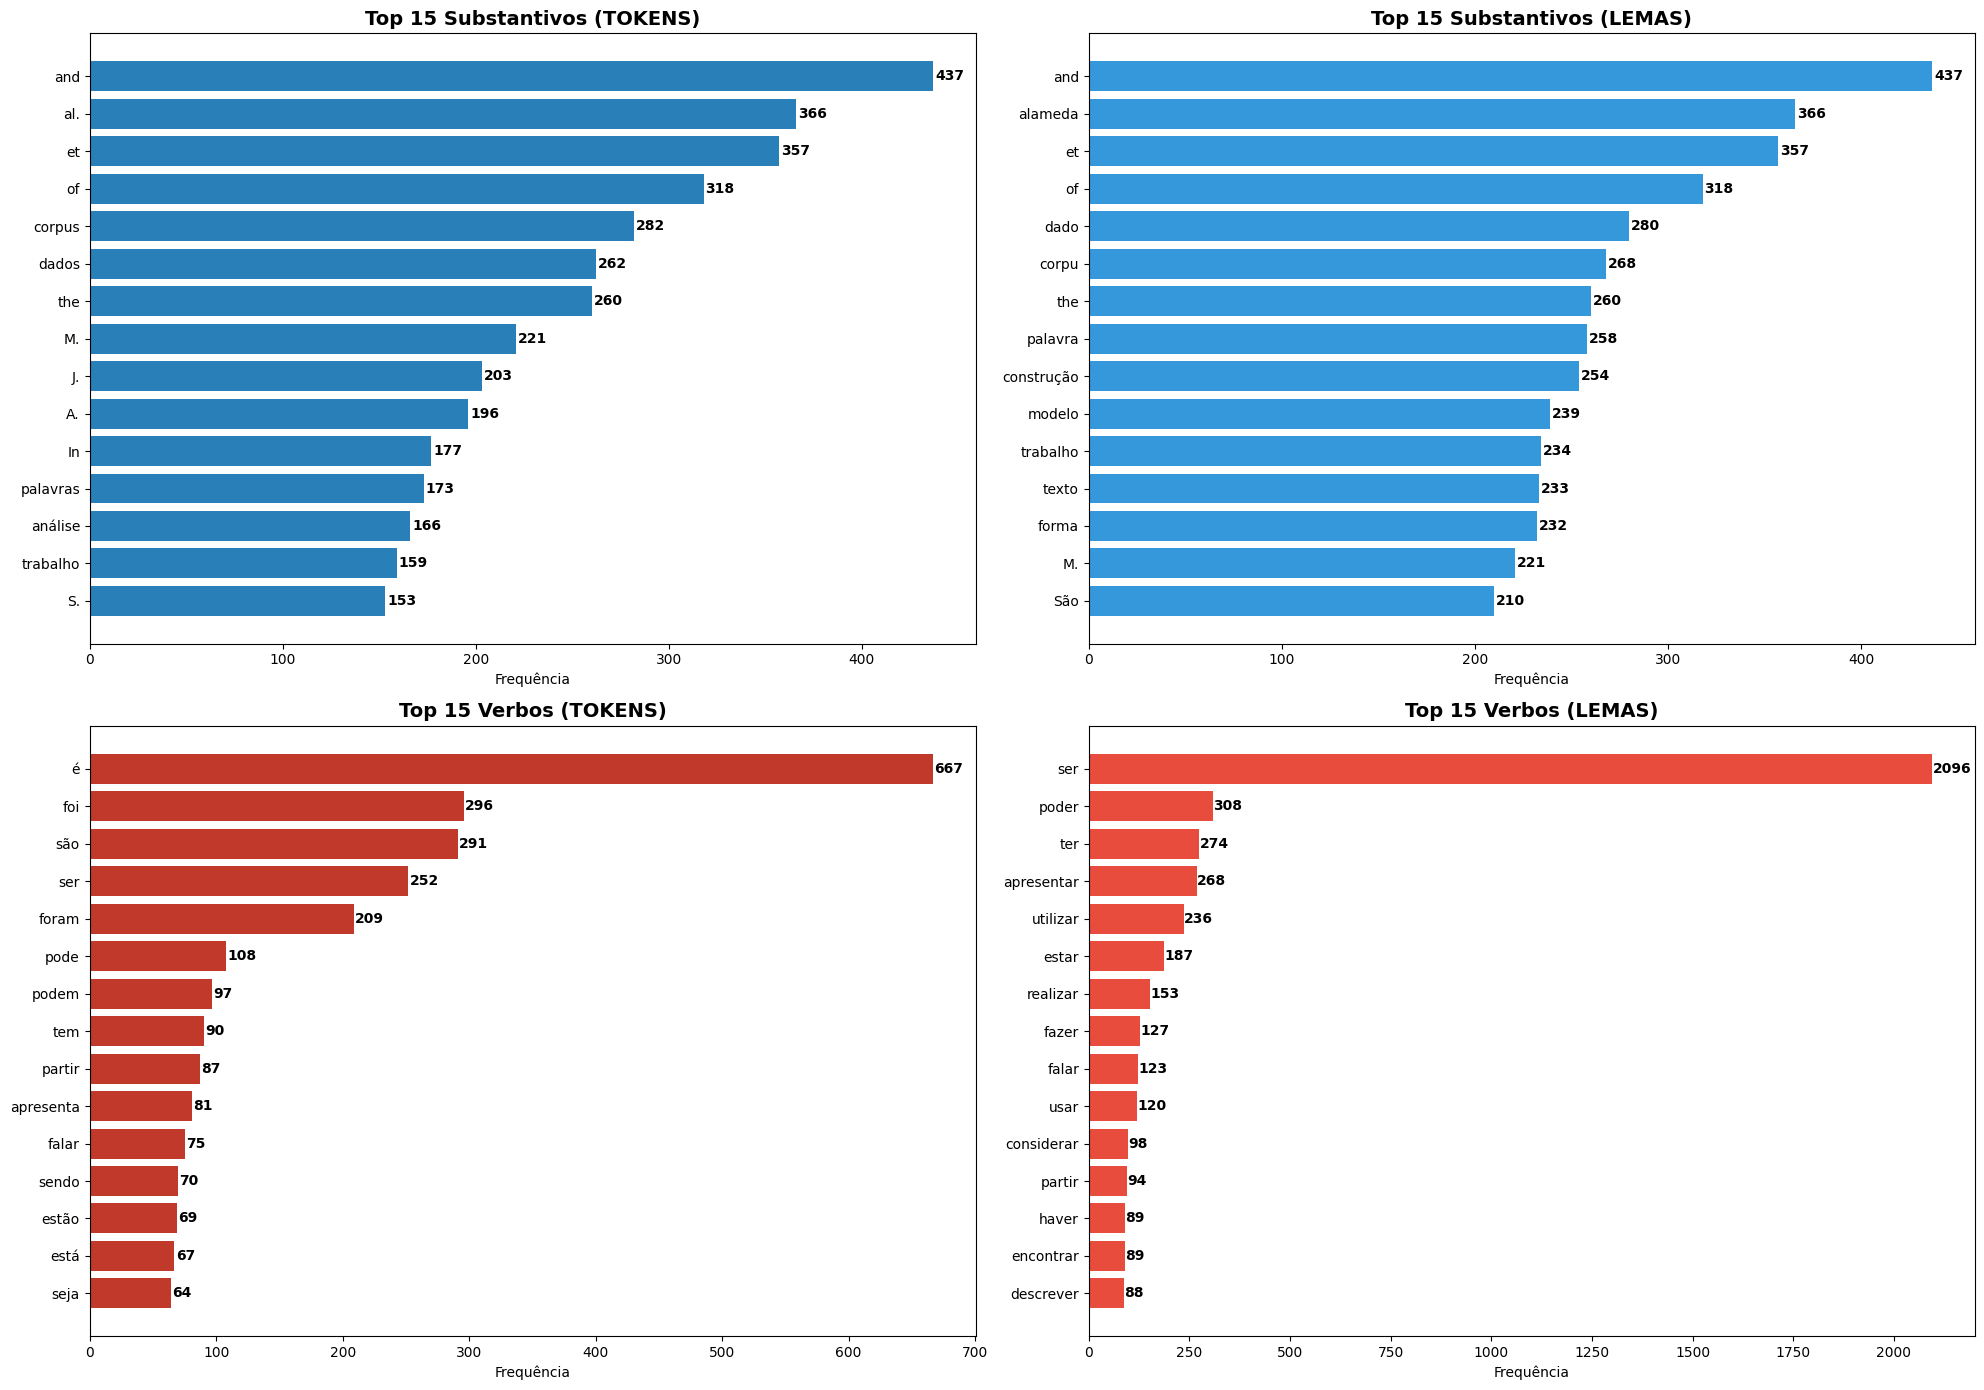

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Substantivos - Tokens
top_sub_tok = dict(freq_sub_tokens.most_common(15))
axes[0, 0].barh(list(top_sub_tok.keys()), list(top_sub_tok.values()), color='#2980b9')
axes[0, 0].set_title('Top 15 Substantivos (TOKENS)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Frequência')
axes[0, 0].invert_yaxis()
for i, (k, v) in enumerate(top_sub_tok.items()):
    axes[0, 0].text(v + 1, i, str(v), va='center', fontweight='bold')

# Substantivos - Lemas
top_sub_lem = dict(freq_sub_lemmas.most_common(15))
axes[0, 1].barh(list(top_sub_lem.keys()), list(top_sub_lem.values()), color='#3498db')
axes[0, 1].set_title('Top 15 Substantivos (LEMAS)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Frequência')
axes[0, 1].invert_yaxis()
for i, (k, v) in enumerate(top_sub_lem.items()):
    axes[0, 1].text(v + 1, i, str(v), va='center', fontweight='bold')

# Verbos - Tokens
top_verb_tok = dict(freq_verb_tokens.most_common(15))
axes[1, 0].barh(list(top_verb_tok.keys()), list(top_verb_tok.values()), color='#c0392b')
axes[1, 0].set_title('Top 15 Verbos (TOKENS)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Frequência')
axes[1, 0].invert_yaxis()
for i, (k, v) in enumerate(top_verb_tok.items()):
    axes[1, 0].text(v + 1, i, str(v), va='center', fontweight='bold')

# Verbos - Lemas
top_verb_lem = dict(freq_verb_lemmas.most_common(15))
axes[1, 1].barh(list(top_verb_lem.keys()), list(top_verb_lem.values()), color='#e74c3c')
axes[1, 1].set_title('Top 15 Verbos (LEMAS)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Frequência')
axes[1, 1].invert_yaxis()
for i, (k, v) in enumerate(top_verb_lem.items()):
    axes[1, 1].text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()


## 4. Distribuição das Classes Gramaticais (POS Tags)

In [35]:
print("\nDistribuição das Classes Gramaticais:")
print(f"{'POS Tag':<8} {'Descrição':<30} {'Contagem':>10} {'%':>8}")
print("-" * 60)

ud_desc = {
    'NOUN': 'Substantivo',
    'VERB': 'Verbo',
    'ADJ': 'Adjetivo',
    'ADV': 'Advérbio',
    'ADP': 'Preposição',
    'DET': 'Determinante (artigos, etc)',
    'PRON': 'Pronome',
    'PROPN': 'Nome próprio',
    'AUX': 'Verbo auxiliar',
    'SCONJ': 'Conjunção subordinativa',
    'CCONJ': 'Conjunção coordenativa',
    'NUM': 'Numeral',
    'PUNCT': 'Pontuação',
    'SYM': 'Símbolo',
    'INTJ': 'Interjeição',
    'X': 'Outro/Desconhecido'
}

pos_counts = Counter(all_tags)
total_tags = len(all_tags)

for tag, count in pos_counts.most_common():
    desc = ud_desc.get(tag, 'Desconhecido')
    pct = count / total_tags * 100
    print(f"{tag:<8} {desc:<30} {count:>10,} {pct:>7.2f}%")


Distribuição das Classes Gramaticais:
POS Tag  Descrição                        Contagem        %
------------------------------------------------------------
NOUN     Substantivo                        23,200   18.33%
PUNCT    Pontuação                          22,348   17.65%
PROPN    Nome próprio                       17,290   13.66%
ADP      Preposição                         15,852   12.52%
DET      Determinante (artigos, etc)        14,377   11.36%
VERB     Verbo                               8,772    6.93%
ADJ      Adjetivo                            6,319    4.99%
NUM      Numeral                             4,438    3.51%
CCONJ    Conjunção coordenativa              2,765    2.18%
ADV      Advérbio                            2,727    2.15%
PRON     Pronome                             2,394    1.89%
AUX      Verbo auxiliar                      2,281    1.80%
X        Outro/Desconhecido                  1,977    1.56%
SCONJ    Conjunção subordinativa             1,548    1.22%


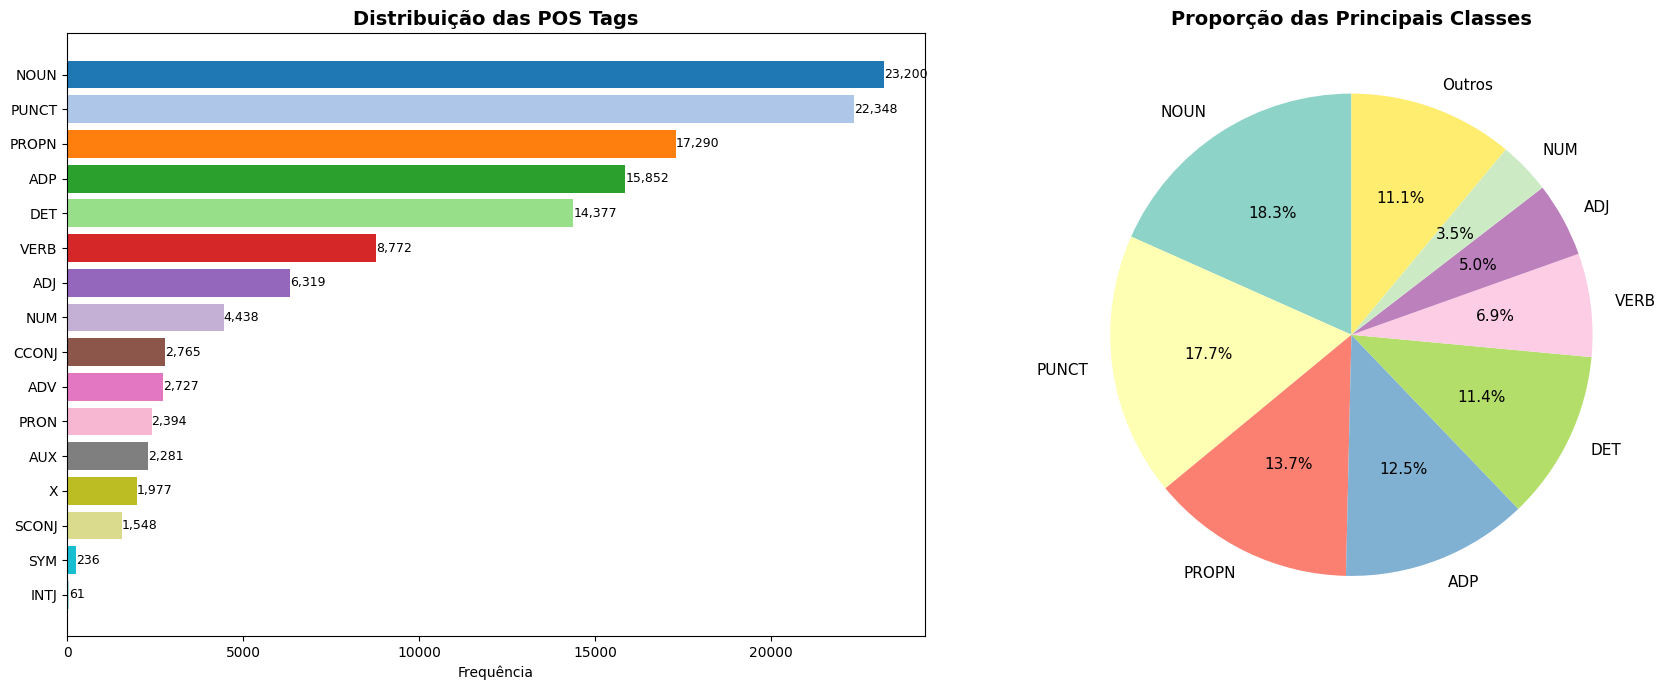

In [36]:
# Gráfico
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Barras horizontais
tags_ordenadas = [tag for tag, _ in pos_counts.most_common()]
contagens = [count for _, count in pos_counts.most_common()]
cores = plt.cm.tab20(np.linspace(0, 1, len(tags_ordenadas)))

ax1.barh(tags_ordenadas, contagens, color=cores)
ax1.set_title('Distribuição das POS Tags', fontsize=14, fontweight='bold')
ax1.set_xlabel('Frequência')
ax1.invert_yaxis()
for i, (tag, count) in enumerate(zip(tags_ordenadas, contagens)):
    ax1.text(count + 1, i, f'{count:,}', va='center', fontsize=9)

# Pizza (top 8 + outros)
top8 = dict(pos_counts.most_common(8))
outros = sum(pos_counts.values()) - sum(top8.values())
top8['Outros'] = outros

ax2.pie(top8.values(), labels=top8.keys(), autopct='%1.1f%%',
        colors=plt.cm.Set3(np.linspace(0, 1, len(top8))),
        startangle=90, textprops={'fontsize': 11})
ax2.set_title('Proporção das Principais Classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. BERTimbau - Embeddings

In [37]:
import os
from transformers import BertTokenizer, BertModel

# Definir diretório para salvar o modelo localmente
MODEL_DIR = '../data/bertimbau_model'
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'

print("=" * 60)
print("DOWNLOAD DO BERTimbau - MODO LOCAL")
print("=" * 60)

# Verificar se o modelo já existe localmente
if os.path.exists(MODEL_DIR) and os.path.exists(os.path.join(MODEL_DIR, 'config.json')):
    print(f"Modelo já existe em: {MODEL_DIR}")
    print("   Carregando do diretório local...")
else:
    print(f"Modelo não encontrado em: {MODEL_DIR}")

# Carregar do diretório local
print("\nCarregando BERTimbau do diretório local...")
tokenizer = BertTokenizer.from_pretrained(MODEL_DIR)
bert_model = BertModel.from_pretrained(MODEL_DIR, output_hidden_states=True)
bert_model.to(device)
bert_model.eval()

print("BERTimbau carregado com sucesso!")
print(f"   Diretório: {MODEL_DIR}")
print(f"   Vocabulário: {tokenizer.vocab_size:,} tokens")
print("    Embeddings: 768 dimensões")
print(f"   Dispositivo: {device}")

# Listar arquivos do modelo
print(f"\nArquivos do modelo em {MODEL_DIR}:")
for file in os.listdir(MODEL_DIR):
    size_mb = os.path.getsize(os.path.join(MODEL_DIR, file)) / (1024 * 1024)
    print(f"   {file} ({size_mb:.1f} MB)")

DOWNLOAD DO BERTimbau - MODO LOCAL
Modelo já existe em: ../data/bertimbau_model
   Carregando do diretório local...

Carregando BERTimbau do diretório local...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16584.21it/s]
[transformers] BertModel LOAD REPORT from: ../data/bertimbau_model
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTimbau carregado com sucesso!
   Diretório: ../data/bertimbau_model
   Vocabulário: 29,794 tokens
    Embeddings: 768 dimensões
   Dispositivo: cpu

Arquivos do modelo em ../data/bertimbau_model:
   config.json (0.0 MB)
   pytorch_model.bin (417.9 MB)
   tokenizer_config.txt (0.0 MB)
   vocab.txt (0.2 MB)


In [38]:
#  Gera embedding contextualizado com BERTimbau
def gerar_embedding(palavra, modelo, tokenizer, dispositivo):
    contexto = f"A {palavra} é um conceito fundamental neste estudo acadêmico."
    
    tokens = tokenizer(contexto, return_tensors='pt', truncation=True, padding=True, max_length=128)
    tokens = {k: v.to(dispositivo) for k, v in tokens.items()}
    
    with torch.no_grad():
        outputs = modelo(**tokens)
    
    embedding = outputs.last_hidden_state.mean(dim=1)
    return embedding.cpu().numpy()

## 6. QUESTÃO 1: Vetores Gerados para as Palavras

In [39]:
print("\n" + "="*80)
print("QUESTÃO 1: VETORES GERADOS PARA AS PALAVRAS")
print("="*80)

# Palavras alvo
palavras_alvo = {
    'a': 'modelos',
    'b': 'linguagem',
    'c': sub_mais_freq[0],
    'd': verb_mais_freq[0]
}

print("\nPalavras a serem analisadas:")
print("   a) 'modelos'")
print("   b) 'linguagem'")
print(f"  c) '{palavras_alvo['c']}' (substantivo mais frequente: {sub_mais_freq[1]}x)")
print(f"  d) '{palavras_alvo['d']}' (verbo mais frequente: {verb_mais_freq[1]}x)")

embeddings = {}

for letra, palavra in palavras_alvo.items():
    print(f"\n{'='*60}")
    print(f"{letra}) Palavra: '{palavra}'")
    print(f"{'='*60}")
    
    emb = gerar_embedding(palavra, bert_model, tokenizer, device)
    embeddings[palavra] = emb
    
    print(f"  Dimensão do vetor: {emb.shape}")
    print("  Vetor (primeiros 10 valores):")
    print(f"     [{', '.join(f'{v:.6f}' for v in emb[0, :10])}]")
    
    print("\nEstatísticas do vetor:")
    print(f"     Média:     {np.mean(emb):.6f}")
    print(f"     Desvio:    {np.std(emb):.6f}")
    print(f"     Mínimo:    {np.min(emb):.6f}")
    print(f"     Máximo:    {np.max(emb):.6f}")
    print(f"     Mediana:   {np.median(emb):.6f}")
    print(f"     Norma L2:  {np.linalg.norm(emb):.4f}")


QUESTÃO 1: VETORES GERADOS PARA AS PALAVRAS

Palavras a serem analisadas:
   a) 'modelos'
   b) 'linguagem'
  c) 'and' (substantivo mais frequente: 437x)
  d) 'ser' (verbo mais frequente: 2096x)

a) Palavra: 'modelos'
  Dimensão do vetor: (1, 768)
  Vetor (primeiros 10 valores):
     [0.101167, -0.495652, 0.796943, 0.064172, 0.553321, 0.303264, 0.140561, -0.167519, 0.404133, 0.019548]

Estatísticas do vetor:
     Média:     -0.000379
     Desvio:    0.240276
     Mínimo:    -0.855279
     Máximo:    0.838798
     Mediana:   0.006115
     Norma L2:  6.6587

b) Palavra: 'linguagem'
  Dimensão do vetor: (1, 768)
  Vetor (primeiros 10 valores):
     [0.058766, -0.322676, 0.779384, 0.007062, 0.493309, 0.190689, 0.051359, -0.139416, 0.350717, 0.030201]

Estatísticas do vetor:
     Média:     -0.000786
     Desvio:    0.243982
     Mínimo:    -0.833924
     Máximo:    0.779384
     Mediana:   0.003853
     Norma L2:  6.7614

c) Palavra: 'and'
  Dimensão do vetor: (1, 768)
  Vetor (primeiros 

## 7. QUESTÃO 2: Termos Mais Similares

In [40]:
print("\n" + "="*80)
print("QUESTÃO 2: TERMOS MAIS SIMILARES")
print("="*80)

def encontrar_similares(palavra_alvo, todos_tokens, embeddings_dict, modelo, tokenizer, dispositivo, top_n=5):
    if palavra_alvo not in embeddings_dict:
        return []
    
    emb_alvo = embeddings_dict[palavra_alvo]
    
    candidatos = list(set([
        str(t) for t in todos_tokens 
        if str(t) != palavra_alvo and len(str(t)) > 1
    ]))
    
    if len(candidatos) > 200:
        np.random.seed(42)
        indices = np.random.choice(len(candidatos), 200, replace=False)
        candidatos = [candidatos[i] for i in indices]
    
    print(f"  Buscando entre {len(candidatos):,} candidatos...")
    
    similaridades = []
    for i, candidato in enumerate(candidatos):
        if (i + 1) % 50 == 0:
            print(f"     Processados {i+1}/{len(candidatos)}...")
        try:
            emb_cand = gerar_embedding(candidato, modelo, tokenizer, dispositivo)
            sim = cosine_similarity(emb_alvo, emb_cand)[0][0]
            similaridades.append((candidato, sim))
        except:
            continue
    
    similaridades.sort(key=lambda x: x[1], reverse=True)
    return similaridades[:top_n]

for letra, palavra in palavras_alvo.items():
    print(f"\n{'='*60}")
    print(f"{letra}) Termos mais similares a '{palavra}':")
    print(f"{'='*60}")
    
    similares = encontrar_similares(
        palavra, all_tokens, embeddings,
        bert_model, tokenizer, device, top_n=5
    )
    
    if similares:
        print(f"\n  {'Nº':<6} {'Termo':<30} {'Similaridade':<15}")
        print(f"  {'-'*55}")
        for i, (termo, score) in enumerate(similares, 1):
            print(f"  {i:<6} {termo:<30} {score:<15.4f}")
    else:
        print("  Nenhum similar encontrado")


QUESTÃO 2: TERMOS MAIS SIMILARES

a) Termos mais similares a 'modelos':
  Buscando entre 200 candidatos...
     Processados 50/200...
     Processados 100/200...
     Processados 150/200...
     Processados 200/200...

  Nº     Termo                          Similaridade   
  -------------------------------------------------------
  1      aplicativos                    0.9872         
  2      controlada                     0.9858         
  3      79                             0.9855         
  4      aplicado                       0.9854         
  5      isolada                        0.9853         

b) Termos mais similares a 'linguagem':
  Buscando entre 200 candidatos...
     Processados 50/200...
     Processados 100/200...
     Processados 150/200...
     Processados 200/200...

  Nº     Termo                          Similaridade   
  -------------------------------------------------------
  1      Linguagem                      1.0000         
  2      Prosa              

## 8. Matriz de Similaridade


Matriz de Similaridade entre as Palavras Alvo:


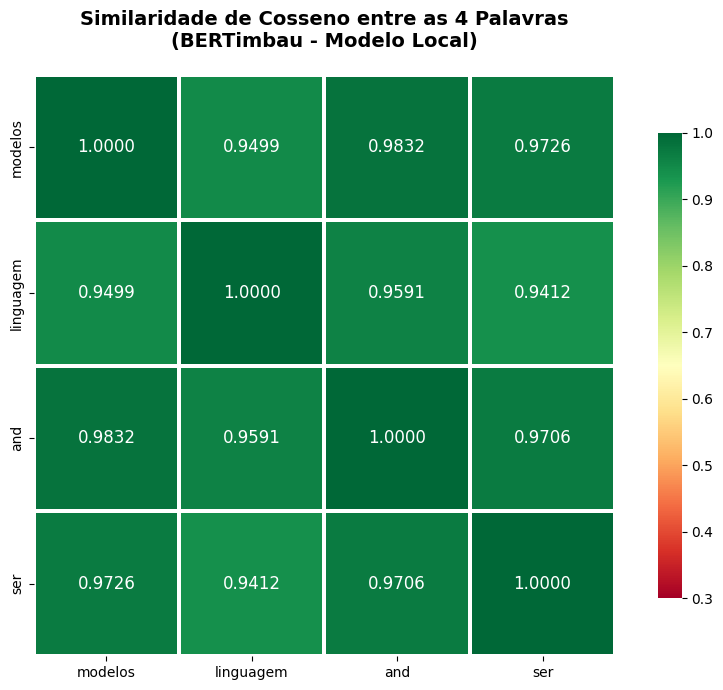


 Similaridades detalhadas:
Palavra 1                 Palavra 2                 Similaridade   
-----------------------------------------------------------------
modelos                   linguagem                 0.9499
modelos                   and                       0.9832
modelos                   ser                       0.9726
linguagem                 and                       0.9591
linguagem                 ser                       0.9412
and                       ser                       0.9706


In [41]:
print("\nMatriz de Similaridade entre as Palavras Alvo:")

palavras_lista = list(embeddings.keys())
n = len(palavras_lista)
matriz_sim = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        matriz_sim[i][j] = cosine_similarity(
            embeddings[palavras_lista[i]], 
            embeddings[palavras_lista[j]]
        )[0][0]

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_sim, 
            annot=True, 
            fmt='.4f',
            xticklabels=palavras_lista,
            yticklabels=palavras_lista,
            cmap='RdYlGn',
            vmin=0.3, 
            vmax=1.0,
            square=True,
            linewidths=1.5,
            linecolor='white',
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 12})
plt.title('Similaridade de Cosseno entre as 4 Palavras\n(BERTimbau - Modelo Local)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n Similaridades detalhadas:")
print(f"{'Palavra 1':<25} {'Palavra 2':<25} {'Similaridade':<15}")
print("-" * 65)
for i in range(n):
    for j in range(i+1, n):
        print(f"{palavras_lista[i]:<25} {palavras_lista[j]:<25} {matriz_sim[i][j]:.4f}")

## 9. QUESTÃO 3: Classificação de Estilo de Escrita

In [43]:
print("\n" + "="*80)
print("QUESTÃO 3: CLASSIFICAÇÃO DE ESTILO DE ESCRITA")
print("="*80)

print("""
    DEFINIÇÃO DOS ESTILOS  
      
    ACADÊMICO: 3ª pessoa, voz passiva, formal, impessoal
    NARRATIVO: 1ª pessoa plural, fluido, reflexivo, ensaio
    DESCRITIVO: Rigor matemático, frases curtas, objetividade
""")


QUESTÃO 3: CLASSIFICAÇÃO DE ESTILO DE ESCRITA

    DEFINIÇÃO DOS ESTILOS  

    ACADÊMICO: 3ª pessoa, voz passiva, formal, impessoal
    NARRATIVO: 1ª pessoa plural, fluido, reflexivo, ensaio
    DESCRITIVO: Rigor matemático, frases curtas, objetividade



In [44]:
def classificar_estilo_escrita(texto):
    texto_original = str(texto)
    texto_lower = texto_original.lower()
    palavras_lower = texto_lower.split()
    
    score_acad = 0
    score_narr = 0
    score_desc = 0
    
    # Marcadores
    marcadores_academicos = [
        'observou-se', 'verificou-se', 'constatou-se', 'notou-se',
        'foi realizado', 'foi observado', 'foi analisado', 'foi desenvolvido',
        'foi aplicado', 'foi utilizado', 'foi considerado', 'foi demonstrado',
        'procedeu-se', 'realizou-se', 'obteve-se', 'concluiu-se',
        'pode-se', 'deve-se', 'trata-se', 'destaca-se',
        'foram analisados', 'foram observados', 'foram utilizados',
        'it was', 'was performed', 'was observed', 'was conducted'
    ]
    
    marcadores_narrativos = [
        'analisamos', 'observamos', 'consideramos', 'investigamos',
        'nosso estudo', 'nossa pesquisa', 'nosso trabalho', 'nossa análise',
        'nós', 'propomos', 'desenvolvemos', 'acreditamos', 'sugerimos',
        'nossa abordagem', 'nosso objetivo', 'nossa proposta',
        'we analyzed', 'we observed', 'we propose', 'our study'
    ]
    
    marcadores_descritivos = [
        'média', 'mediana', 'desvio padrão', 'p-valor', 'p valor',
        'correlação', 'significativamente', 'estatisticamente',
        'percentual', 'porcentagem', 'frequência', 'amostra',
        'variância', 'intervalo de confiança', 'regressão',
        'coeficiente', 'significância', 'normalidade', 'distribuição',
        'mean', 'median', 'standard deviation', 'p-value',
        'correlation', 'significantly', 'statistically'
    ]
    
    for marcador in marcadores_academicos:
        score_acad += texto_lower.count(marcador)
    for marcador in marcadores_narrativos:
        score_narr += texto_lower.count(marcador)
    for marcador in marcadores_descritivos:
        score_desc += texto_lower.count(marcador)
    
    # Análise estrutural
    import re
    frases = [f.strip() for f in texto_lower.replace('!', '.').replace('?', '.').split('.') if f.strip()]
    if frases:
        tamanho_medio = np.mean([len(f.split()) for f in frases])
        if tamanho_medio <= 15:
            score_desc += 2
        elif tamanho_medio >= 30:
            score_acad += 1
            score_narr += 1
    
    numeros = len(re.findall(r'\d+\.?\d*', texto_original))
    if numeros > 10:
        score_desc += 3
    elif numeros > 5:
        score_desc += 2
    elif numeros > 2:
        score_desc += 1
    
    pronomes_1a = ['nós', 'nosso', 'nossa', 'we', 'our']
    for p in pronomes_1a:
        if p in palavras_lower:
            score_narr += 2
    
    if '-se' in texto_lower or ' se ' in texto_lower:
        score_acad += 1
    
    scores = {'Acadêmico': score_acad, 'Narrativo': score_narr, 'Descritivo': score_desc}
    estilo = max(scores, key=scores.get)
    
    if all(v == 0 for v in scores.values()):
        estilo = 'Acadêmico'
    
    return estilo, scores

# Classificar
print("Classificando artigos...")
resultados = df['artigo_completo'].apply(classificar_estilo_escrita)
df['estilo'] = resultados.apply(lambda x: x[0])
df['scores'] = resultados.apply(lambda x: x[1])

# Distribuição
print("\n Distribuição dos Estilos:")
print(f"{'Estilo':<15} {'Nº Artigos':<12} {'Percentual':<12}")
print("-" * 42)
for estilo, count in df['estilo'].value_counts().items():
    pct = count / len(df) * 100
    print(f"{estilo:<15} {count:<12} {pct:>6.1f}%")

# Mapear labels
estilo_to_id = {'Acadêmico': 0, 'Narrativo': 1, 'Descritivo': 2}
id_to_estilo = {v: k for k, v in estilo_to_id.items()}
df['label'] = df['estilo'].map(estilo_to_id)



Classificando artigos...

 Distribuição dos Estilos:
Estilo          Nº Artigos   Percentual  
------------------------------------------
Descritivo      18             60.0%
Narrativo       6              20.0%
Acadêmico       6              20.0%


## 10. Resumo Final e Salvamento

In [47]:
print("\n" + "="*80)
print("RESUMO FINAL - AP5")
print("="*80)

print(f"""
      RESPOSTAS AP5

      QUESTÃO 1 - Vetores Gerados: 
        a) 'modelos'
        b) 'linguagem'  
        c) '{sub_mais_freq[0]}'
        d) '{verb_mais_freq[0]}'

        QUESTÃO 2 - Termos Similares:
        Ver resultados na Seção 7

        QUESTÃO 3 - Classificação de Estilo:
        
        • Modelo: BERTimbau (download local)
        • Classes: Acadêmico, Narrativo, Descritivo 
        • Artigos: {len(df):<4}
""")

# Salvar resultados
resultados_final = {
    "modelo": "BERTimbau (neuralmind/bert-base-portuguese-cased)",
    "diretorio_modelo": MODEL_DIR,
    "questao_1": {
        "palavras": palavras_alvo,
        "dimensao_embedding": 768
    },
    "questao_2": {
        "substantivo_frequente": list(sub_mais_freq),
        "verbo_frequente": list(verb_mais_freq)
    },
    "questao_3": {
        "estilos": dict(df['estilo'].value_counts()),
        "artigos_classificados": len(df)
    }
}

with open('resultados_ap5.json', 'w', encoding='utf-8') as f:
    json.dump(resultados_final, f, ensure_ascii=False, indent=2, default=str)

print("\nResultados salvos em 'resultados_ap5.json'")
print(f"Modelo salvo em '{MODEL_DIR}'")
print("\nAP5 concluída com sucesso!")


RESUMO FINAL - AP5

      RESPOSTAS AP5

      QUESTÃO 1 - Vetores Gerados: 
        a) 'modelos'
        b) 'linguagem'  
        c) 'and'
        d) 'ser'

        QUESTÃO 2 - Termos Similares:
        Ver resultados na Seção 7

        QUESTÃO 3 - Classificação de Estilo:

        • Modelo: BERTimbau (download local)
        • Classes: Acadêmico, Narrativo, Descritivo 
        • Artigos: 30  


Resultados salvos em 'resultados_ap5.json'
Modelo salvo em '../data/bertimbau_model'

AP5 concluída com sucesso!
